# Stage 5 - Settle the volume deviation

**Input:** the forecast cost per strategy from Stage 4 (`data/forecast_costs.csv`), the forecast
load (`load_mwh` in `data/hedge_energy.csv`), the realised portfolio consumption
(`data/actual_portfolio_load.csv`), the realised Day-Ahead price (`data/day_ahead_prices.csv`) and
the realised imbalance price (`data/imbalance_prices.csv`)

**Output:** the per-quarter-hour imbalance volume (`data/imbalance.csv`) and the final procurement
cost per strategy (`data/final_costs.csv`)

**Task:** settle the deviation of actual consumption from the Day-Ahead schedule at the realised
imbalance price, add it on top of Stage 4's forecast-position cost to get the final procurement
cost, isolate the pure price effect of being imbalanced, and explain why the imbalance settlement
is identical across all three strategies while the futures hedge still does not remove volume /
forecast risk.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

DATA = "../data"
C_CAL, C_GRAN, C_UNHEDGED = "#DD8452", "#4C72B0", "#8172B3"   # COARSE_CAL, GRANULAR, UNHEDGED
STRATEGIES = ["UNHEDGED", "COARSE_CAL", "GRANULAR"]
COLORS = {"UNHEDGED": C_UNHEDGED, "COARSE_CAL": C_CAL, "GRANULAR": C_GRAN}

forecast_costs = pd.read_csv(f"{DATA}/forecast_costs.csv").set_index("strategy").reindex(STRATEGIES)
load      = pd.read_csv(f"{DATA}/hedge_energy.csv")[["timestamp_utc", "load_mwh"]]
actual    = pd.read_csv(f"{DATA}/actual_portfolio_load.csv")
day_ahead = pd.read_csv(f"{DATA}/day_ahead_prices.csv")
imbalance = pd.read_csv(f"{DATA}/imbalance_prices.csv")

df = load.merge(actual[["timestamp_utc", "total_actual_mwh"]], on="timestamp_utc", validate="one_to_one")
df = df.merge(day_ahead[["timestamp_utc", "day_ahead_price_eur_mwh"]], on="timestamp_utc", validate="one_to_one")
df = df.merge(imbalance[["timestamp_utc", "imbalance_price_eur_mwh"]], on="timestamp_utc", validate="one_to_one")
assert df.isna().sum().sum() == 0

print("merged grid:", df.shape, "-> forecast load x realised actual load x Day-Ahead x imbalance price")
print("Stage 4 forecast cost carried forward:")
forecast_costs

merged grid: (35136, 5) -> forecast load x realised actual load x Day-Ahead x imbalance price
Stage 4 forecast cost carried forward:


,C_futures_EUR,C_residual_DA_EUR,C_forecast_EUR,Pi_futures_EUR
strategy,,,,
UNHEDGED,0.00,"3,506,703.99","3,506,703.99",0.00
COARSE_CAL,"3,493,701.73","-42,735.09","3,450,966.64","55,737.35"
GRANULAR,"3,493,705.92","-42,198.57","3,451,507.34","55,196.65"


## 1. Imbalance volume and settlement

During delivery, actual consumption $A_t$ (`total_actual_mwh`) differs from the Day-Ahead schedule.
That schedule is the forecast load $L_t$ under **every** strategy - the futures hedge only changes
how $L_t$ is financed, never what gets scheduled. The imbalance volume is therefore:

$$I_t = A_t - L_t$$

settled at the realised imbalance price $P_t^{imb}$ (reBAP):

$$C_{imb} = \sum_t I_t \cdot P_t^{imb}$$

Final procurement cost adds this on top of Stage 4's forecast-position cost:

$$C_{final} = C_{futures} + C_{residual}^{DA} + C_{imb}$$

and the pure price consequence of *being* imbalanced - stripping out the volume itself - is:

$$Premium_{imb} = \sum_t I_t \cdot \big(P_t^{imb} - P_t^{DA}\big)$$

In [2]:
df["I_t"] = df["total_actual_mwh"] - df["load_mwh"]   # same for every strategy: L_t is strategy-independent

C_imb = (df["I_t"] * df["imbalance_price_eur_mwh"]).sum()
Premium_imb = (df["I_t"] * (df["imbalance_price_eur_mwh"] - df["day_ahead_price_eur_mwh"])).sum()

final_costs = forecast_costs[["C_futures_EUR", "C_residual_DA_EUR", "C_forecast_EUR"]].copy()
final_costs["C_imb_EUR"] = C_imb
final_costs["Premium_imb_EUR"] = Premium_imb
final_costs["C_final_EUR"] = final_costs["C_futures_EUR"] + final_costs["C_residual_DA_EUR"] + final_costs["C_imb_EUR"]
final_costs["saving_vs_UNHEDGED_EUR"] = final_costs.loc["UNHEDGED", "C_final_EUR"] - final_costs["C_final_EUR"]

print(f"total imbalance volume: {df['I_t'].sum():,.1f} MWh net "
      f"(actual {df['total_actual_mwh'].sum():,.1f} vs. forecast {df['load_mwh'].sum():,.1f} MWh)")
print("C_imb and Premium_imb are identical across strategies - see Section 2.")
final_costs

total imbalance volume: 138.0 MWh net (actual 43,138.0 vs. forecast 43,000.0 MWh)
C_imb and Premium_imb are identical across strategies - see Section 2.


,C_futures_EUR,C_residual_DA_EUR,C_forecast_EUR,C_imb_EUR,Premium_imb_EUR,C_final_EUR,saving_vs_UNHEDGED_EUR
strategy,,,,,,,
UNHEDGED,0.00,"3,506,703.99","3,506,703.99","30,503.84","13,589.24","3,537,207.83",0.00
COARSE_CAL,"3,493,701.73","-42,735.09","3,450,966.64","30,503.84","13,589.24","3,481,470.48","55,737.35"
GRANULAR,"3,493,705.92","-42,198.57","3,451,507.34","30,503.84","13,589.24","3,482,011.18","55,196.65"


**Interpreting `imbalance_volume` ($I_t$).**

- **Positive** ($A_t > L_t$): the company consumed more than scheduled - it is short. The missing
  energy is bought at $P_t^{imb}$; the cashflow $I_t \cdot P_t^{imb}$ is a cost whenever the
  imbalance price is positive. reBAP is set to *penalise* the system's net direction, so a systemic
  shortage (many suppliers short at once, as during a cold snap) tends to coincide with $P_t^{imb}$
  spiking well above $P_t^{DA}$ - exactly when being short is most expensive.
- **Negative** ($A_t < L_t$): the company consumed less than scheduled - it is long. The surplus is
  sold back at $P_t^{imb}$; the cashflow is a credit (a cost reduction) whenever the price is
  positive, but that credit shrinks (or turns into a cost) if $P_t^{imb}$ is unusually low in that
  quarter-hour.

Over 2024 the portfolio was net **long** in most months but net short overall by about 138 MWh
(actual 43,138 vs. forecast 43,000 MWh), and `Premium_imb` is positive (+13,589 EUR): on average
across the imbalanced quarter-hours, $P_t^{imb}$ realised above $P_t^{DA}$ - consistent with the
system-wide penalty pattern above and with a small net cost from being imbalanced, on top of the
volume itself.

**Why $C_{imb}$ and $Premium_{imb}$ are identical for all three strategies.** $I_t = A_t - L_t$
never involves $H_t$: the Day-Ahead schedule is the same forecast portfolio regardless of how much
of it was pre-hedged with futures. The futures hedge changes *how the forecast position is
financed* (fixed futures price vs. Day-Ahead price on the residual, Stage 4) - it has no effect
whatsoever on the gap between the forecast and what customers actually consume. **The risk the
futures hedge does not remove is volume/forecast risk**: no combination of Base and Peak futures,
however finely sliced, can hedge a forecasting error that is only known after the fact. Only a
better forecast (or demand-side flexibility) would reduce $C_{imb}$; the hedge only ever acts on
$L_t$, never on $A_t$.

## 2. Visualize the final cost

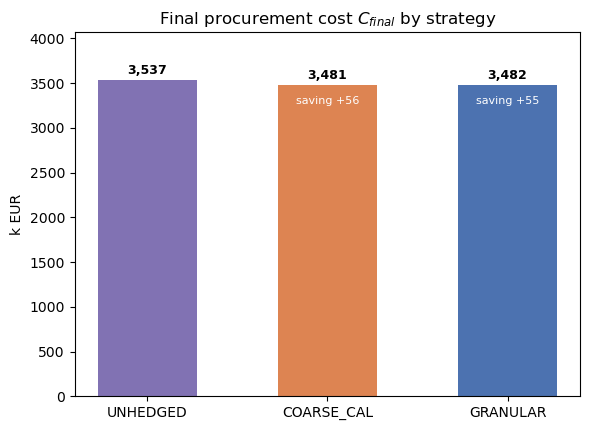

In [3]:
xs = np.arange(3)
vals = final_costs.loc[STRATEGIES, "C_final_EUR"].values / 1000

fig, ax = plt.subplots(figsize=(6, 4.4))
ax.bar(xs, vals, color=[COLORS[s] for s in STRATEGIES], width=0.55)
ax.set_xticks(xs); ax.set_xticklabels(STRATEGIES)
ax.set_ylabel("k EUR"); ax.set_title(r"Final procurement cost $C_{final}$ by strategy")
ax.set_ylim(0, vals.max() * 1.15)
for xi, v, strategy in zip(xs, vals, STRATEGIES):
    ax.annotate(f"{v:,.0f}", (xi, v), xytext=(0, 4), textcoords="offset points",
                ha="center", fontsize=9, fontweight="bold")
    if strategy != "UNHEDGED":
        saving = final_costs.loc[strategy, "saving_vs_UNHEDGED_EUR"] / 1000
        ax.annotate(f"saving {saving:+,.0f}", (xi, v), xytext=(0, -14), textcoords="offset points",
                     ha="center", fontsize=8, color="white")

plt.tight_layout(); plt.show()

**Comment.** Both hedged strategies save a bit over 55k EUR against `UNHEDGED` on this
realised 2024 price path - almost entirely from `C_futures` + `C_residual^DA` (Stage 4), since
`C_imb` is, by construction, exactly the same 30.5k EUR for all three (Section 1). `COARSE_CAL`
comes out marginally cheaper than `GRANULAR` here even though Stage 3 found `GRANULAR` had the
better shape fit (lower RMSE) - a reminder that a single realised price path is one draw, not proof
that the finer hedge is "better"; Stage 6 compares risk, not just this one year's cost.

## 3. Save the settlement result

In [4]:
imbalance_out = df[["timestamp_utc", "load_mwh", "total_actual_mwh", "I_t", "imbalance_price_eur_mwh", "day_ahead_price_eur_mwh"]] \
    .rename(columns={"I_t": "imbalance_volume_mwh"})
imbalance_out.to_csv(f"{DATA}/imbalance.csv", index=False)

final_costs_out = final_costs.rename_axis("strategy").reset_index()
final_costs_out.to_csv(f"{DATA}/final_costs.csv", index=False)

print("saved:", f"{DATA}/imbalance.csv", imbalance_out.shape)
print("saved:", f"{DATA}/final_costs.csv", final_costs_out.shape)
final_costs_out

saved: ../data/imbalance.csv (35136, 6)
saved: ../data/final_costs.csv (3, 8)


,strategy,C_futures_EUR,C_residual_DA_EUR,C_forecast_EUR,C_imb_EUR,Premium_imb_EUR,C_final_EUR,saving_vs_UNHEDGED_EUR
0,UNHEDGED,0.00,"3,506,703.99","3,506,703.99","30,503.84","13,589.24","3,537,207.83",0.00
1,COARSE_CAL,"3,493,701.73","-42,735.09","3,450,966.64","30,503.84","13,589.24","3,481,470.48","55,737.35"
2,GRANULAR,"3,493,705.92","-42,198.57","3,451,507.34","30,503.84","13,589.24","3,482,011.18","55,196.65"
